In [1]:
import numpy as np
import corner
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy
from scipy.stats import norm
import pandas as pd
import time


In [2]:
df_nld_talys=pd.read_csv("NLD_c0p0.csv")
df_nld_talys= df_nld_talys.drop(df_nld_talys.index[:2]) #drop weird dip at beginning

energy_nld_talys=df_nld_talys["Ex"].values # as numpy array
nld_talys=df_nld_talys["NLD"].values 

In [3]:
'''c = 0
p = 2.3

prev = 0
new_nld = []
new_err = []
np.random.seed()

shifted_energy = energy_nld_talys+p
sqrt_erg = np.sqrt(shifted_energy)
sqrt_erg[np.isnan(sqrt_erg)] = 0
exp = np.exp(c*sqrt_erg)

#nld_shift = np.interp(shifted_energy,energy_nld_talys,nld_talys)
for i in range(len(exp)):

    nld = exp[i]*nld_talys[i]
    noise = np.random.normal(1, 0.5)  # Gaussian noise with mean=1 and std=0.1
    new_y = nld * noise
    if new_y > prev:
        prev = new_y
    else:
        new_y = prev
    error = np.random.normal(loc=0.1, scale=nld * 0.1)  #make errorbar w/ Mean=0, std=10% of nld
    if error < 0:
        error = -error
    new_nld.append(new_y)
    new_err.append(error*(i+1)*.5) #scalars for "realism"
'''

'c = 0\np = 2.3\n\nprev = 0\nnew_nld = []\nnew_err = []\nnp.random.seed()\n\nshifted_energy = energy_nld_talys+p\nsqrt_erg = np.sqrt(shifted_energy)\nsqrt_erg[np.isnan(sqrt_erg)] = 0\nexp = np.exp(c*sqrt_erg)\n\n#nld_shift = np.interp(shifted_energy,energy_nld_talys,nld_talys)\nfor i in range(len(exp)):\n\n    nld = exp[i]*nld_talys[i]\n    noise = np.random.normal(1, 0.5)  # Gaussian noise with mean=1 and std=0.1\n    new_y = nld * noise\n    if new_y > prev:\n        prev = new_y\n    else:\n        new_y = prev\n    error = np.random.normal(loc=0.1, scale=nld * 0.1)  #make errorbar w/ Mean=0, std=10% of nld\n    if error < 0:\n        error = -error\n    new_nld.append(new_y)\n    new_err.append(error*(i+1)*.5) #scalars for "realism"\n'

In [4]:
a0 = 1
a1 = 2
x = np.linspace(0,10)
y = a0+a1*x
y_err = np.ones((1,len(y)))*1
print(y)

[ 1.          1.40816327  1.81632653  2.2244898   2.63265306  3.04081633
  3.44897959  3.85714286  4.26530612  4.67346939  5.08163265  5.48979592
  5.89795918  6.30612245  6.71428571  7.12244898  7.53061224  7.93877551
  8.34693878  8.75510204  9.16326531  9.57142857  9.97959184 10.3877551
 10.79591837 11.20408163 11.6122449  12.02040816 12.42857143 12.83673469
 13.24489796 13.65306122 14.06122449 14.46938776 14.87755102 15.28571429
 15.69387755 16.10204082 16.51020408 16.91836735 17.32653061 17.73469388
 18.14285714 18.55102041 18.95918367 19.36734694 19.7755102  20.18367347
 20.59183673 21.        ]


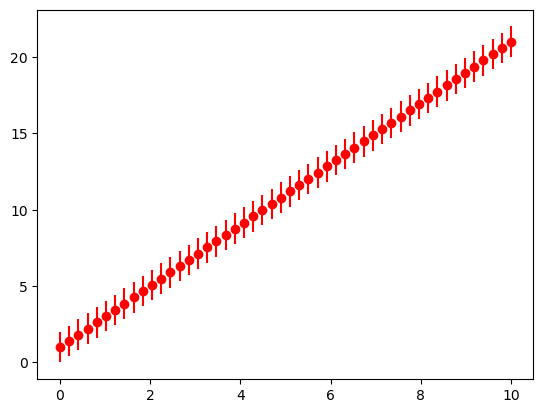

In [5]:
fig = plt.figure()

plt.errorbar(x,y,yerr=y_err,color="r",fmt='o')
#plt.errorbar(shifted_energy,new_nld,yerr=new_err,fmt='o',label=f'Gen. Data c = {c}, p ={p}')
#plt.yscale("log")

#plt.xlim(0, 20)
#plt.ylim(10**(0),10**(6))

#plt.legend(loc ='upper left',fontsize="x-large")
plt.show()

In [6]:
def model(param0,param1,erg=x):
    vals=[]
    vals.append(param0+param1*erg)
    return vals[0]

In [7]:
def likely(param0,param1,data):
    likelihood_log_val=0
    true = model(param0,param1)
    sigmas = y_err[0]
    for i in range(0,len(data)):
        likelihood_log_val=likelihood_log_val-1/2*((data[i] -true[i]) / sigmas[i])**2
        -np.log(2*np.pi*sigmas[i]**2)/2
    return likelihood_log_val,param0,param1

In [8]:
np.random.seed()
results = []
for i in range(0,10000):
    #parhaps use a cost function to minimize ask Chat
    a0_guess = np.random.uniform(-3,3)
    a1_guess = np.random.uniform(-3,3)
    llv = likely(a0_guess,a1_guess,y)
    results.append(llv)

In [9]:
best_a0 = max(results)[1]
best_a1 = max(results)[2]
print(best_a0)

0.9666455588198781


In [10]:
y_guess= max(results)[1] + max(results)[2]*x

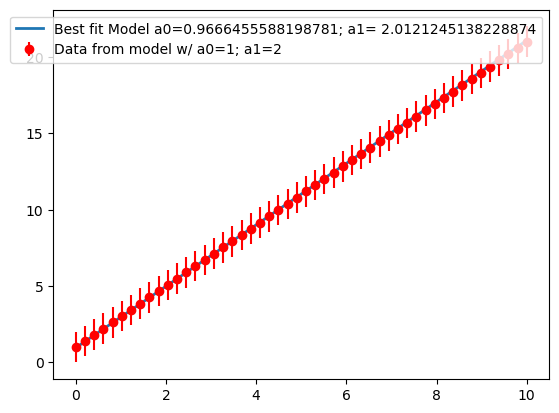

In [11]:
fig1 = plt.figure()


plt.errorbar(x,y,yerr=y_err,color="r",fmt='o',label = f'Data from model w/ a0={a0}; a1={a1}')
plt.plot(x,y_guess,label=f'Best fit Model a0={best_a0}; a1= {best_a1}',lw=2)
#plt.yscale("log")

#plt.xlim(0, 20)
#plt.ylim(10**(0),10**(6))

plt.legend()
plt.show()

Now to shift points around

In [13]:
np.random.seed(1034276)
# y_shift = y+np.random.normal(loc=1,scale=y_err)

y_shift = y+np.random.normal(loc=0,scale=y_err[0])

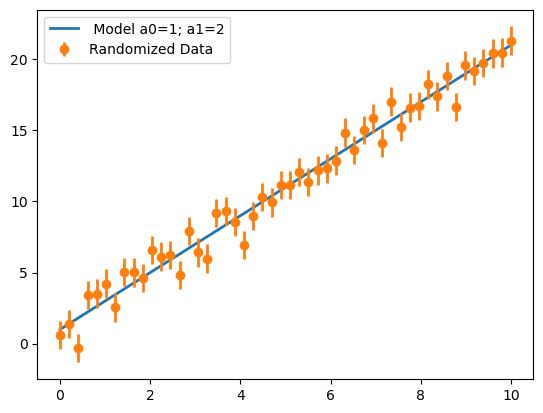

In [14]:
fig2 = plt.figure()
plt.plot(x,y,label=f' Model a0={a0}; a1={a1}',lw=2)
plt.errorbar(x,y_shift,yerr=y_err[0],fmt='o',label=f'Randomized Data ',lw=2)
plt.legend()
plt.show()

In [15]:
shift_results = []
for a in range(0,10000):
    a0_guess = np.random.uniform(-3,3)
    a1_guess = np.random.uniform(-3,3)
    llv = likely(a0_guess,a1_guess,data=y_shift)
    shift_results.append(llv)
shift_guess= max(shift_results)[1] + max(shift_results)[2]*x

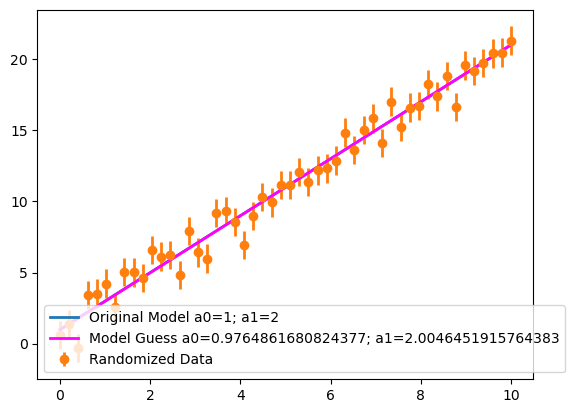

In [16]:
fig3 = plt.figure()

plt.plot(x,y,label=f'Original Model a0={a0}; a1={a1}',lw=2)
plt.errorbar(x,y_shift,yerr=y_err,fmt='o',label=f'Randomized Data ',lw=2)
plt.plot(x,shift_guess,label=f'Model Guess a0={max(shift_results)[1]}; a1={max(shift_results)[2]}',lw=2,color='magenta')
plt.legend()
plt.show()

In [71]:
def model_A(x,params):
    return params[0]+params[1]*x

def likelihood(params,arguments):
    data, model, sigmas = arguments
    likelihood_log_val=0
    
    for i in range(len(data[0])):
        likelihood_log_val=likelihood_log_val-1/2*((data[1][i] - model(data[0][i],params)) / sigmas[0][i])**2\
        -np.log(2*np.pi*sigmas[0][i]**2)/2   
    return np.exp(likelihood_log_val)

def prior(params_vals,arguments):#how is this built?
    params0,params0_Cov_Inv_matrix=arguments
    mu=np.array(params_vals)-np.array(params0)
    params_size=len(params_vals)
    return (2*np.pi)**(-params_size/2)*np.sqrt(np.linalg.det(params0_Cov_Inv_matrix))*np.exp(-np.dot(mu,np.dot(params0_Cov_Inv_matrix,mu))/2) #


In [73]:
# Define the Metropolis algorithm
def metropolis(data,sigma, prior,prior_arguments, likelihood,model,\
               num_iterations, step_size):
#     step_size should be a list the size of the parameters of the model
    likelihood_arguments=[data, model, sigma]
    initial_parameters=prior_arguments[0]
    #thermalizing
    burn_samples=1000
    # Set the initial state of the chain
    params_current=initial_parameters
    params_list=[]
    posterior_list=[]
    
    acceptance_times=0
    
    cov_step_size=np.diag(step_size)**2
    
    posterior_current=(likelihood(params_current,likelihood_arguments))*(prior(params_current,\
                                                                               prior_arguments))
    
    # Run the Metropolis-Hastings algorithm for burning
    for i in range(burn_samples):
        # Propose a new state for the chain
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        
        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*(prior(params_proposed,\
                                                                               prior_arguments))
        
        # Calculate the acceptance probability
        acceptance_prob = min(1, posterior_proposed / posterior_current)

        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed


    for i in range(num_iterations):
        params_proposed=np.random.multivariate_normal(params_current,cov_step_size)
        
        posterior_proposed=(likelihood(params_proposed,likelihood_arguments))*\
        (prior(params_proposed,prior_arguments))
        
        # Calculate the acceptance probability
        acceptance_prob = min(1, posterior_proposed / posterior_current)

        # Accept or reject the proposal
        if np.random.uniform() < acceptance_prob:
            params_current = params_proposed
            posterior_current=posterior_proposed
            acceptance_times=acceptance_times+1

        # Store the current state
        params_list.append(params_current)
        posterior_list.append(posterior_current)
        
    
    #Rule of thumb acceptance is around 50%. 
    #You could plot the accuracy of the estimations as a function of this rate, that would be interesting to see. 
    print(acceptance_times/num_iterations*100,"%")
    
    return(np.array(params_list),np.array(posterior_list),\
           acceptance_times/num_iterations*100)



In [80]:
#Here I am calculating the values for the Covarience matrix

#store distributions around each parameter
def cov_mtx_2D(val0,val1,sig0,sig1):
    val0_dist = []
    val1_dist = []

    np.random.seed() #setting a seed causes same random numbers to be used each run. no value mean random numbers are different each run randomly
    for i in range(0,1000):
        #Determine range of data around each parameter given a normal distribution
        #Loc is the mean aka the guess for the parameter; scale is the st. dev
        val0_dist.append( norm.ppf(np.random.rand(),loc=val0,scale=sig0) )
        val1_dist.append( norm.ppf(np.random.rand(),loc=val1,scale=sig1) )

    val0_dist = np.array(val0_dist)
    val1_dist = np.array(val1_dist)
   
    dists = np.column_stack((val0_dist,val1_dist))
    covariance_matrix = np.cov(dists,rowvar=False)

    print(covariance_matrix)
    return covariance_matrix, val0_dist, val1_dist

In [88]:
np.random.seed(142857)


a0,a1 = 0,1
cov_mtx = cov_mtx_2D(a0,a1,1,1)[0]
#Setting up the prior
prior_arguments_A=[[a0,a1],cov_mtx]
#prior_arguments_A=[[0,1],np.linalg.inv(np.diag([2**2,2**2]))] #why is this the cov matrix 
#Doing the Metropolis sampling for 100000 values
results_A=metropolis([x,y_shift],y_err, prior,\
                         prior_arguments_A, likelihood,model_A,100000, [0.2,0.2])
all_chains =results_A[0]

print(all_chains)

[[ 1.03489825 -0.0173311 ]
 [-0.0173311   1.01103568]]


C:\Users\th3C0\AppData\Local\Temp\ipykernel_9640\445381275.py:30: RuntimeWarning: invalid value encountered in scalar divide
  acceptance_prob = min(1, posterior_proposed / posterior_current)
C:\Users\th3C0\AppData\Local\Temp\ipykernel_9640\445381275.py:30: RuntimeWarning: divide by zero encountered in scalar divide
  acceptance_prob = min(1, posterior_proposed / posterior_current)


13.089999999999998 %
[[0.84546268 2.03335526]
 [1.22038425 1.99697148]
 [1.22038425 1.99697148]
 ...
 [0.86641633 2.02582663]
 [0.86641633 2.02582663]
 [0.86641633 2.02582663]]


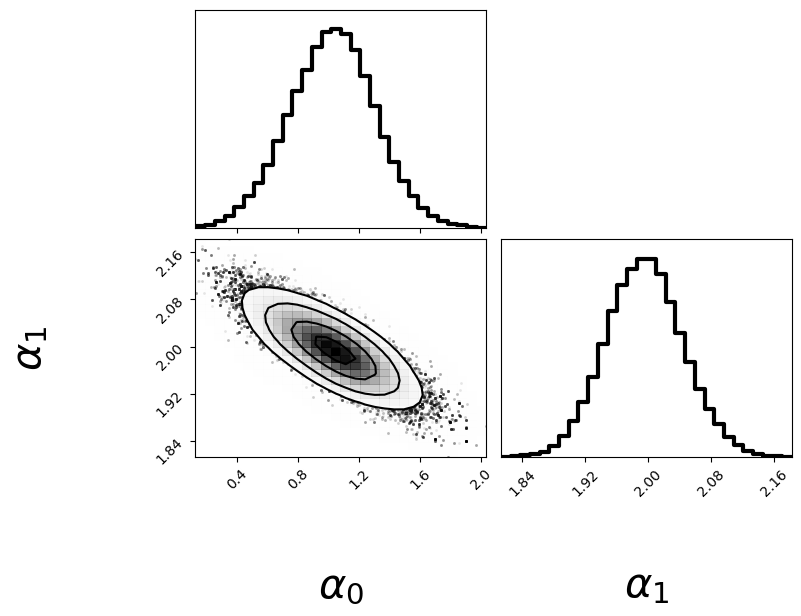

In [90]:
figure = corner.corner(all_chains,
    labels=[r'$\alpha_0$',r'$\alpha_1$'],
    labelpad=0.2,
                       bins=30,
    label_kwargs={"fontsize":30},
                      hist_kwargs= {"linewidth":3},
    quantiles=None
                        ,truths=[0,1], truth_color='r'
                       ,
    smooth=(1.7)
                       ,
    smooth1d=1.0
                      )


width = 8
height = 6
figure.set_size_inches(width, height)
plt.rc('xtick', labelsize=15)    
plt.rc('ytick', labelsize=15)


In [98]:
rng = np.random.default_rng()
alpha_rand = rng.choice(all_chains,(10000),replace=False)
func_rand=[model_A(x,alpha) for alpha in alpha_rand]

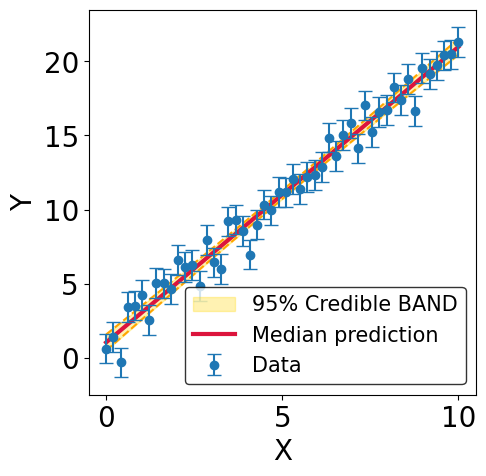

In [110]:
np.random.seed(142857)

x_func= np.linspace(0, 10, 200)
func_rand=[model_A(x_func,alpha) for alpha in alpha_rand]

fig, ax = plt.subplots(figsize=(5,5),dpi=100)
median = np.percentile(func_rand, 50, axis = 0)
upper = (np.percentile(func_rand, 97.5, axis = 0))

prediction_color_number=4

lower = (np.percentile(func_rand, 2.5, axis = 0))


ax.fill_between(x_func, lower, upper, color='gold', alpha=0.3,label='95% Credible BAND')

ax.plot(x_func, median, color='crimson',linewidth=3,label='Median prediction')
ax.plot(x_func, lower, color='orange',linestyle='dashed')
ax.plot(x_func, upper, color='orange',linestyle='dashed')

#If you want to see the true function that generated these, uncomment the following line
#ax.plot(x_func, true_function_A(x_func), label='True Function',color='r', alpha=0.6)

ax.errorbar(x,y_shift, yerr=y_err, fmt='o', capsize=5,label='Data')


plt.legend(fontsize=15,frameon=True, edgecolor='black')


ax.set_xlabel('X',fontsize=20)
ax.set_ylabel('Y',fontsize=20)

plt.rc('xtick', labelsize=20)   
plt.rc('ytick', labelsize=20)

plt.show()